In [31]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

In [68]:
s2_dnbr_dir = r'/Volumes/PhD/imagery/masters/output/dNBR/'

av_HM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/HM1/'
av_OHM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/OHM1/'
nbr_dir = r'/Volumes/PhD/imagery/masters/output/NBR/'

basin = '17346'

out = r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/SI/'

In [69]:
M1_dnbr = rxr.open_rasterio(s2_dnbr_dir + f'basin_{basin}_dNBR.tif', masked=True).squeeze()
HM1_dnbr = rxr.open_rasterio(av_HM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()
OHM1_dnbr = rxr.open_rasterio(av_OHM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()

M1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_S2_NBR_pre.tif', masked=True).squeeze()
M1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_S2_NBR_post.tif', masked=True).squeeze()

HM1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_HM1_AV_NBR_pre.tif', masked=True).squeeze()
HM1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_HM1_AV_NBR_post.tif', masked=True).squeeze()

OHM1_nbr_pre = rxr.open_rasterio(nbr_dir + f'{basin}_OHM1_AV_NBR_pre.tif', masked=True).squeeze()
OHM1_nbr_post = rxr.open_rasterio(nbr_dir + f'{basin}_OHM1_AV_NBR_post.tif', masked=True).squeeze()

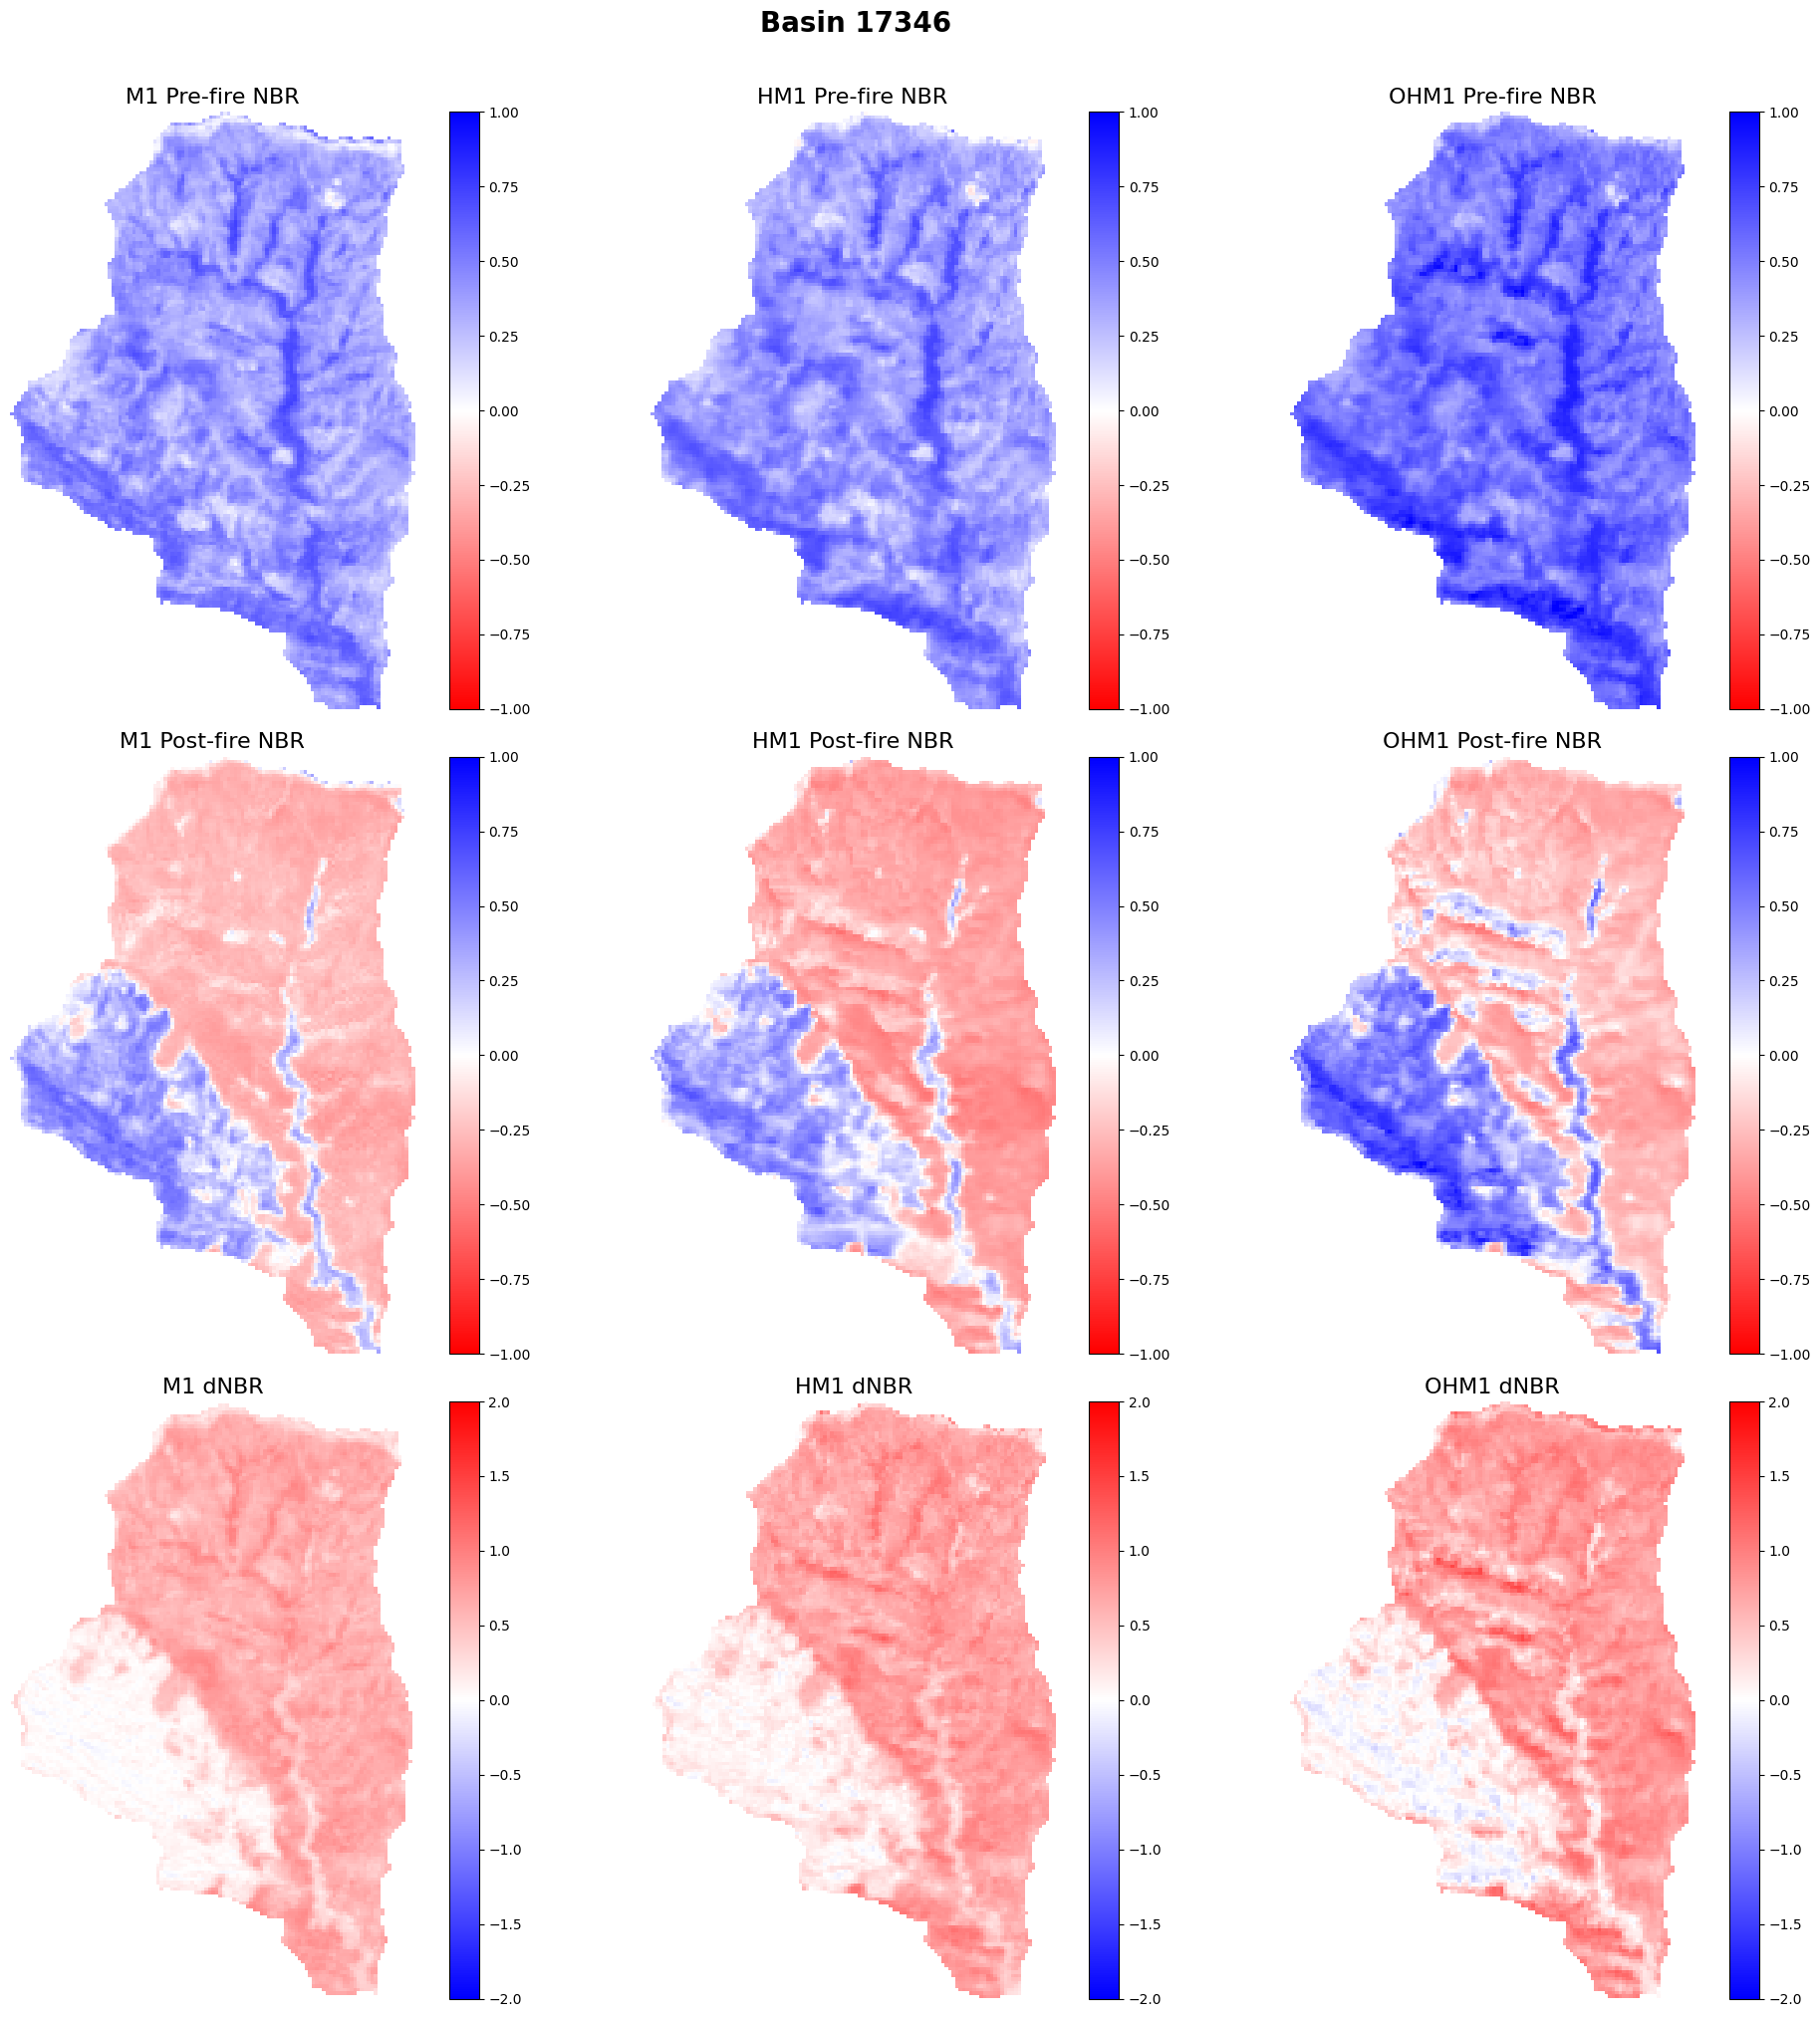

In [30]:
vmin = -1
vmax = 1
vmin_dnbr = -2
vmax_dnbr = 2

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

# Row 1 Pre-fire NBR
im = axes[0, 0].imshow(M1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 0])
axes[0, 0].set_title('M1 Pre-fire NBR', fontsize=16)

im = axes[0, 1].imshow(HM1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 1])
axes[0, 1].set_title('HM1 Pre-fire NBR', fontsize=16)

im = axes[0, 2].imshow(OHM1_nbr_pre, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0, 2])
axes[0, 2].set_title('OHM1 Pre-fire NBR', fontsize=16)

# Row 2 Post-fire NBR
im = axes[1, 0].imshow(M1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 0])
axes[1, 0].set_title('M1 Post-fire NBR', fontsize=16)   

im = axes[1, 1].imshow(HM1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 1])
axes[1, 1].set_title('HM1 Post-fire NBR', fontsize=16)

im = axes[1, 2].imshow(OHM1_nbr_post, cmap='bwr_r', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1, 2])
axes[1, 2].set_title('OHM1 Post-fire NBR', fontsize=16)

# Row 3 dNBR
im = axes[2, 0].imshow(M1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 0])
axes[2, 0].set_title('M1 dNBR', fontsize=16)

im = axes[2, 1].imshow(HM1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 1])
axes[2, 1].set_title('HM1 dNBR', fontsize=16)

im = axes[2, 2].imshow(OHM1_dnbr, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
fig.colorbar(im, ax=axes[2, 2])
axes[2, 2].set_title('OHM1 dNBR', fontsize=16)
for ax in axes.flatten():
    ax.axis('off')
plt.suptitle(f'Basin {basin}', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig(out + f'Basin_{basin}_NBR_dNBR_comparison.png', dpi=600, bbox_inches='tight')
plt.show()


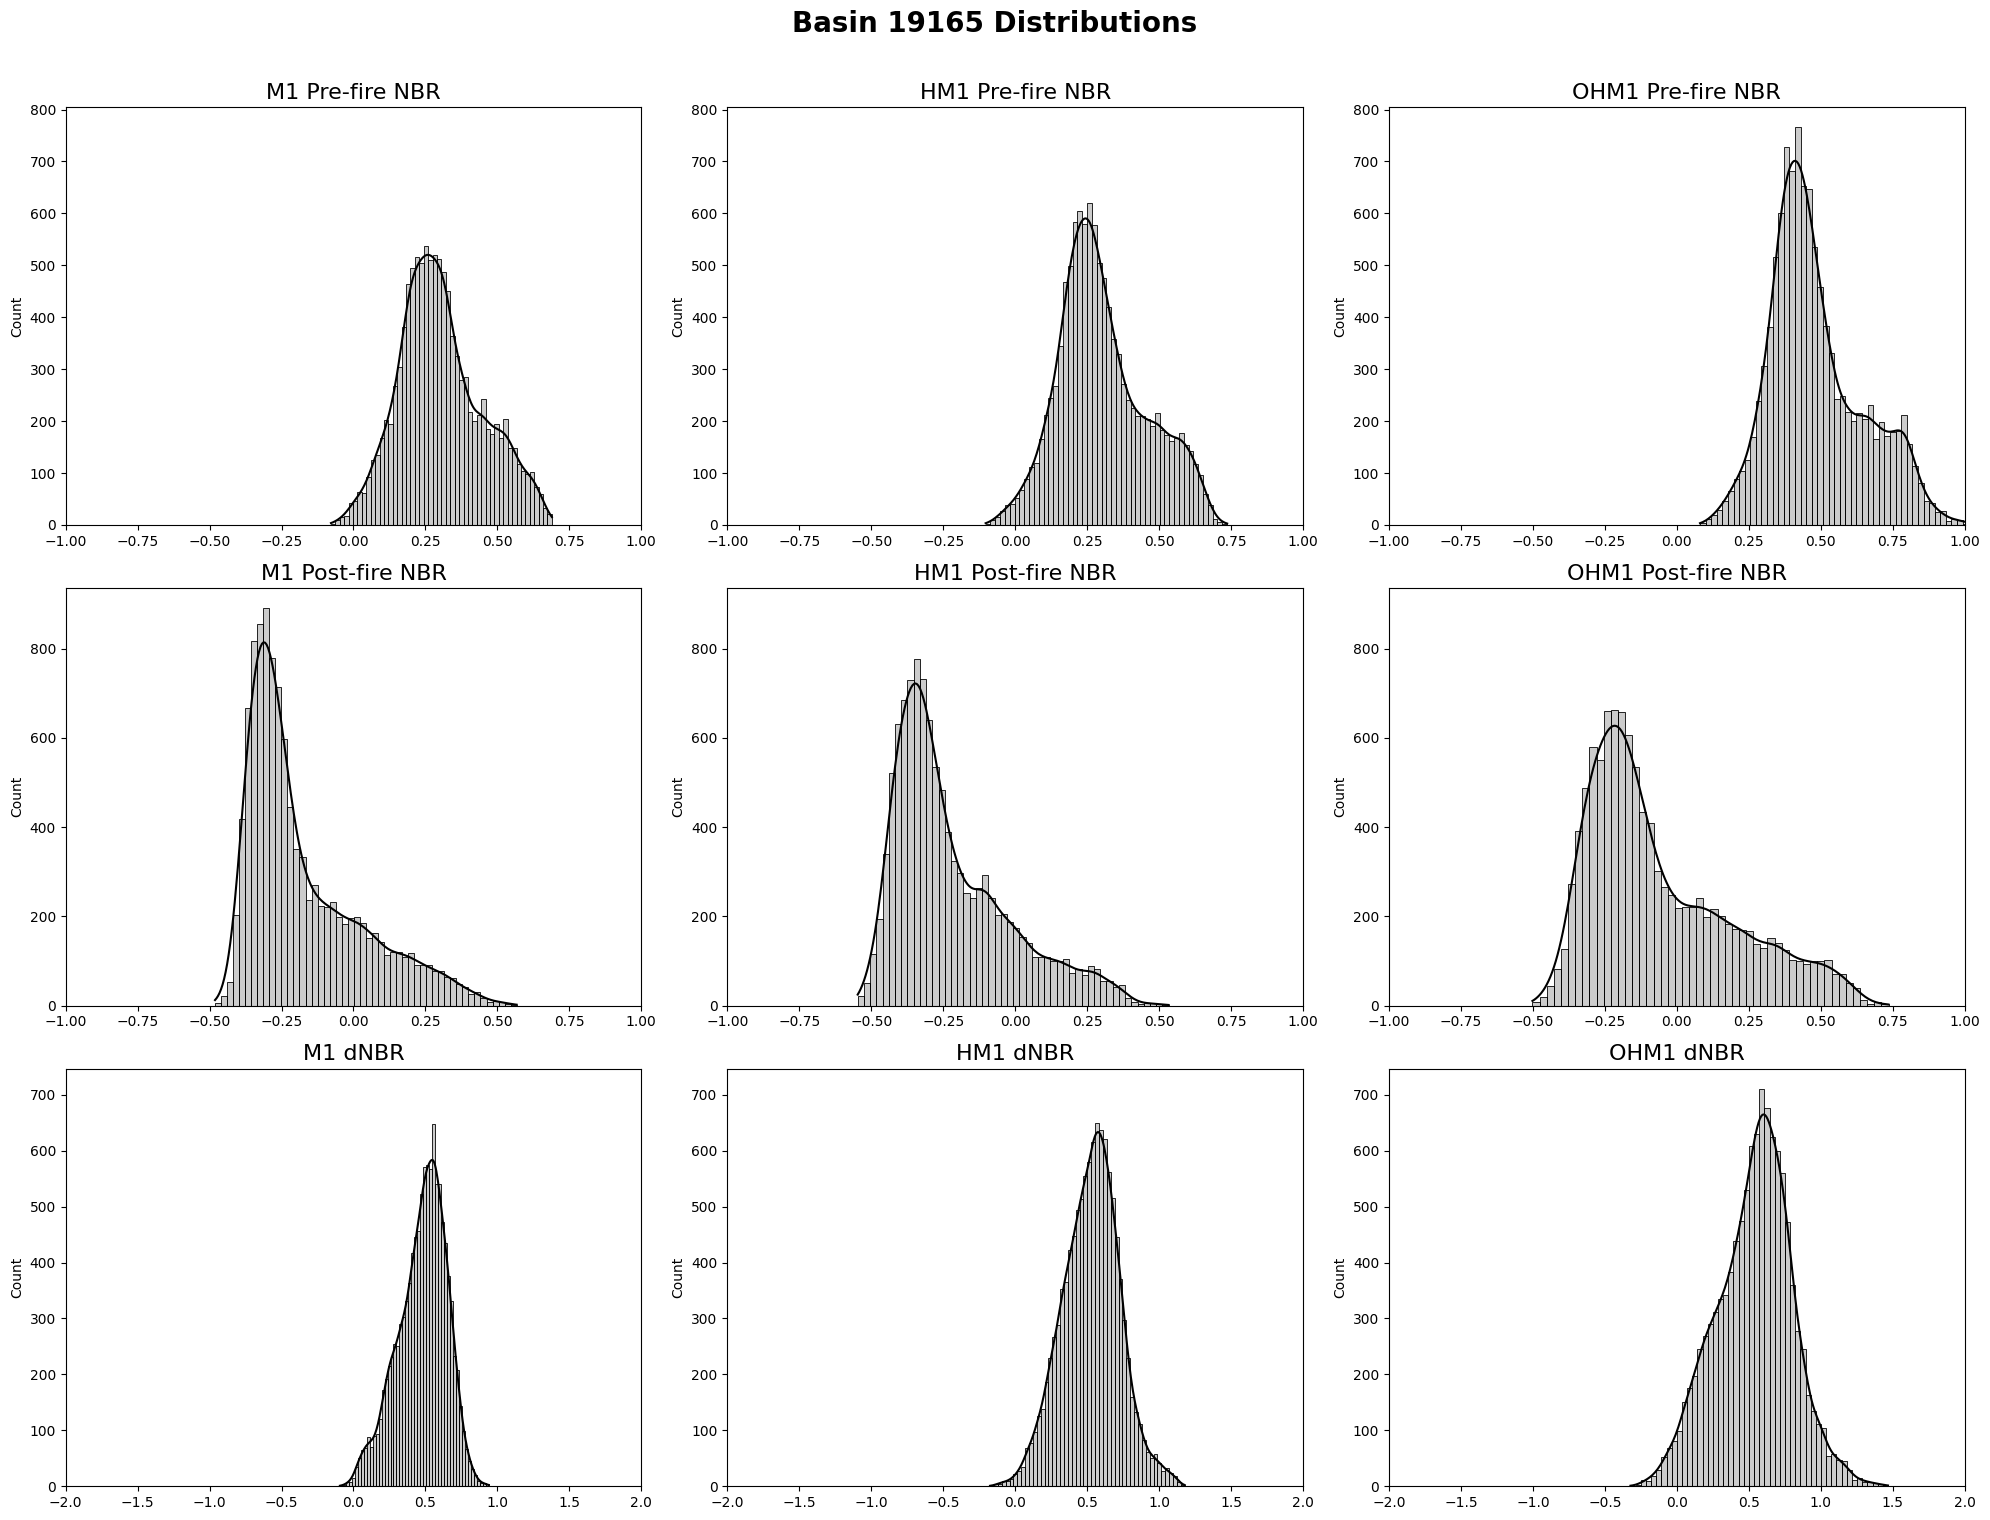

In [60]:
# Plot a 3x3 grid of histograms with titles

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

sns.histplot(M1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 0])
axes[0, 0].set_title('M1 Pre-fire NBR', fontsize=16)

sns.histplot(HM1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 1])
axes[0, 1].set_title('HM1 Pre-fire NBR', fontsize=16)

sns.histplot(OHM1_nbr_pre.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[0, 2])
axes[0, 2].set_title('OHM1 Pre-fire NBR', fontsize=16)

sns.histplot(M1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 0])
axes[1, 0].set_title('M1 Post-fire NBR', fontsize=16)

sns.histplot(HM1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 1])
axes[1, 1].set_title('HM1 Post-fire NBR', fontsize=16)

sns.histplot(OHM1_nbr_post.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[1, 2])
axes[1, 2].set_title('OHM1 Post-fire NBR', fontsize=16)

sns.histplot(M1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 0])
axes[2, 0].set_title('M1 dNBR', fontsize=16)    

sns.histplot(HM1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 1])
axes[2, 1].set_title('HM1 dNBR', fontsize=16)

sns.histplot(OHM1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2, ax=axes[2, 2])
axes[2, 2].set_title('OHM1 dNBR', fontsize=16)

# Row 1 & 2 → NBR
for i in [0, 1]:
    for ax in axes[i, :]:
        ax.set_xlim(-1, 1)

# Row 3 → dNBR
for ax in axes[2, :]:
    ax.set_xlim(-2, 2)
    
for i in range(3):
    row_axes = axes[i, :]
    
    ymax = max(
        max([p.get_height() for p in ax.patches], default=[0])
        for ax in row_axes
    )
    
    for ax in row_axes:
        ax.set_ylim(0, ymax * 1.05)

plt.suptitle(f'Basin {basin} Distributions', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(out + f'Basin_{basin}_distributions_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

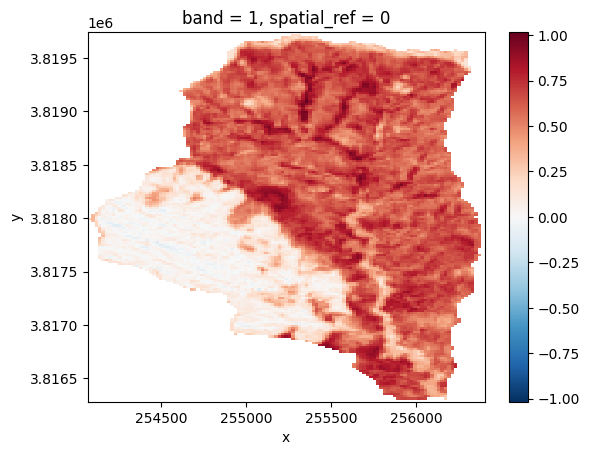

In [4]:
M1_dnbr.plot()

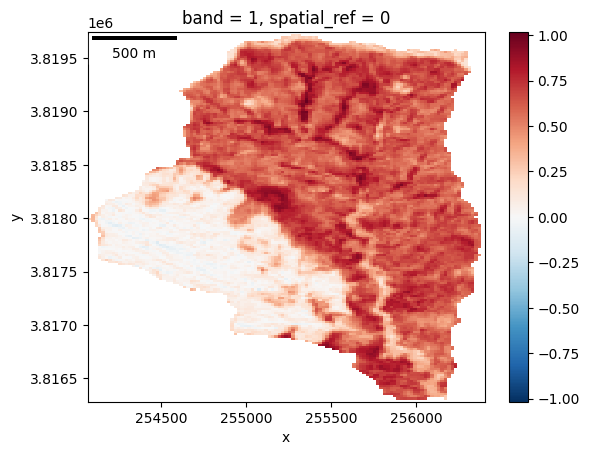

In [27]:
fig, ax = plt.subplots()
M1_dnbr.plot(ax=ax)

# Add scale bar
scalebar = ScaleBar(
    dx=1,           # 1 unit per pixel (meters, since your CRS is projected)
    units="m",
    location="upper left",   # or "lower left", "upper right", etc.
    color="black",
    box_alpha=0.5,
    fixed_value=500,
)
ax.add_artist(scalebar)
plt.show()

/var/folders/mm/sjj0b1k91z39pkxfzn0rj_1h0000gn/T/ipykernel_22436/308796296.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


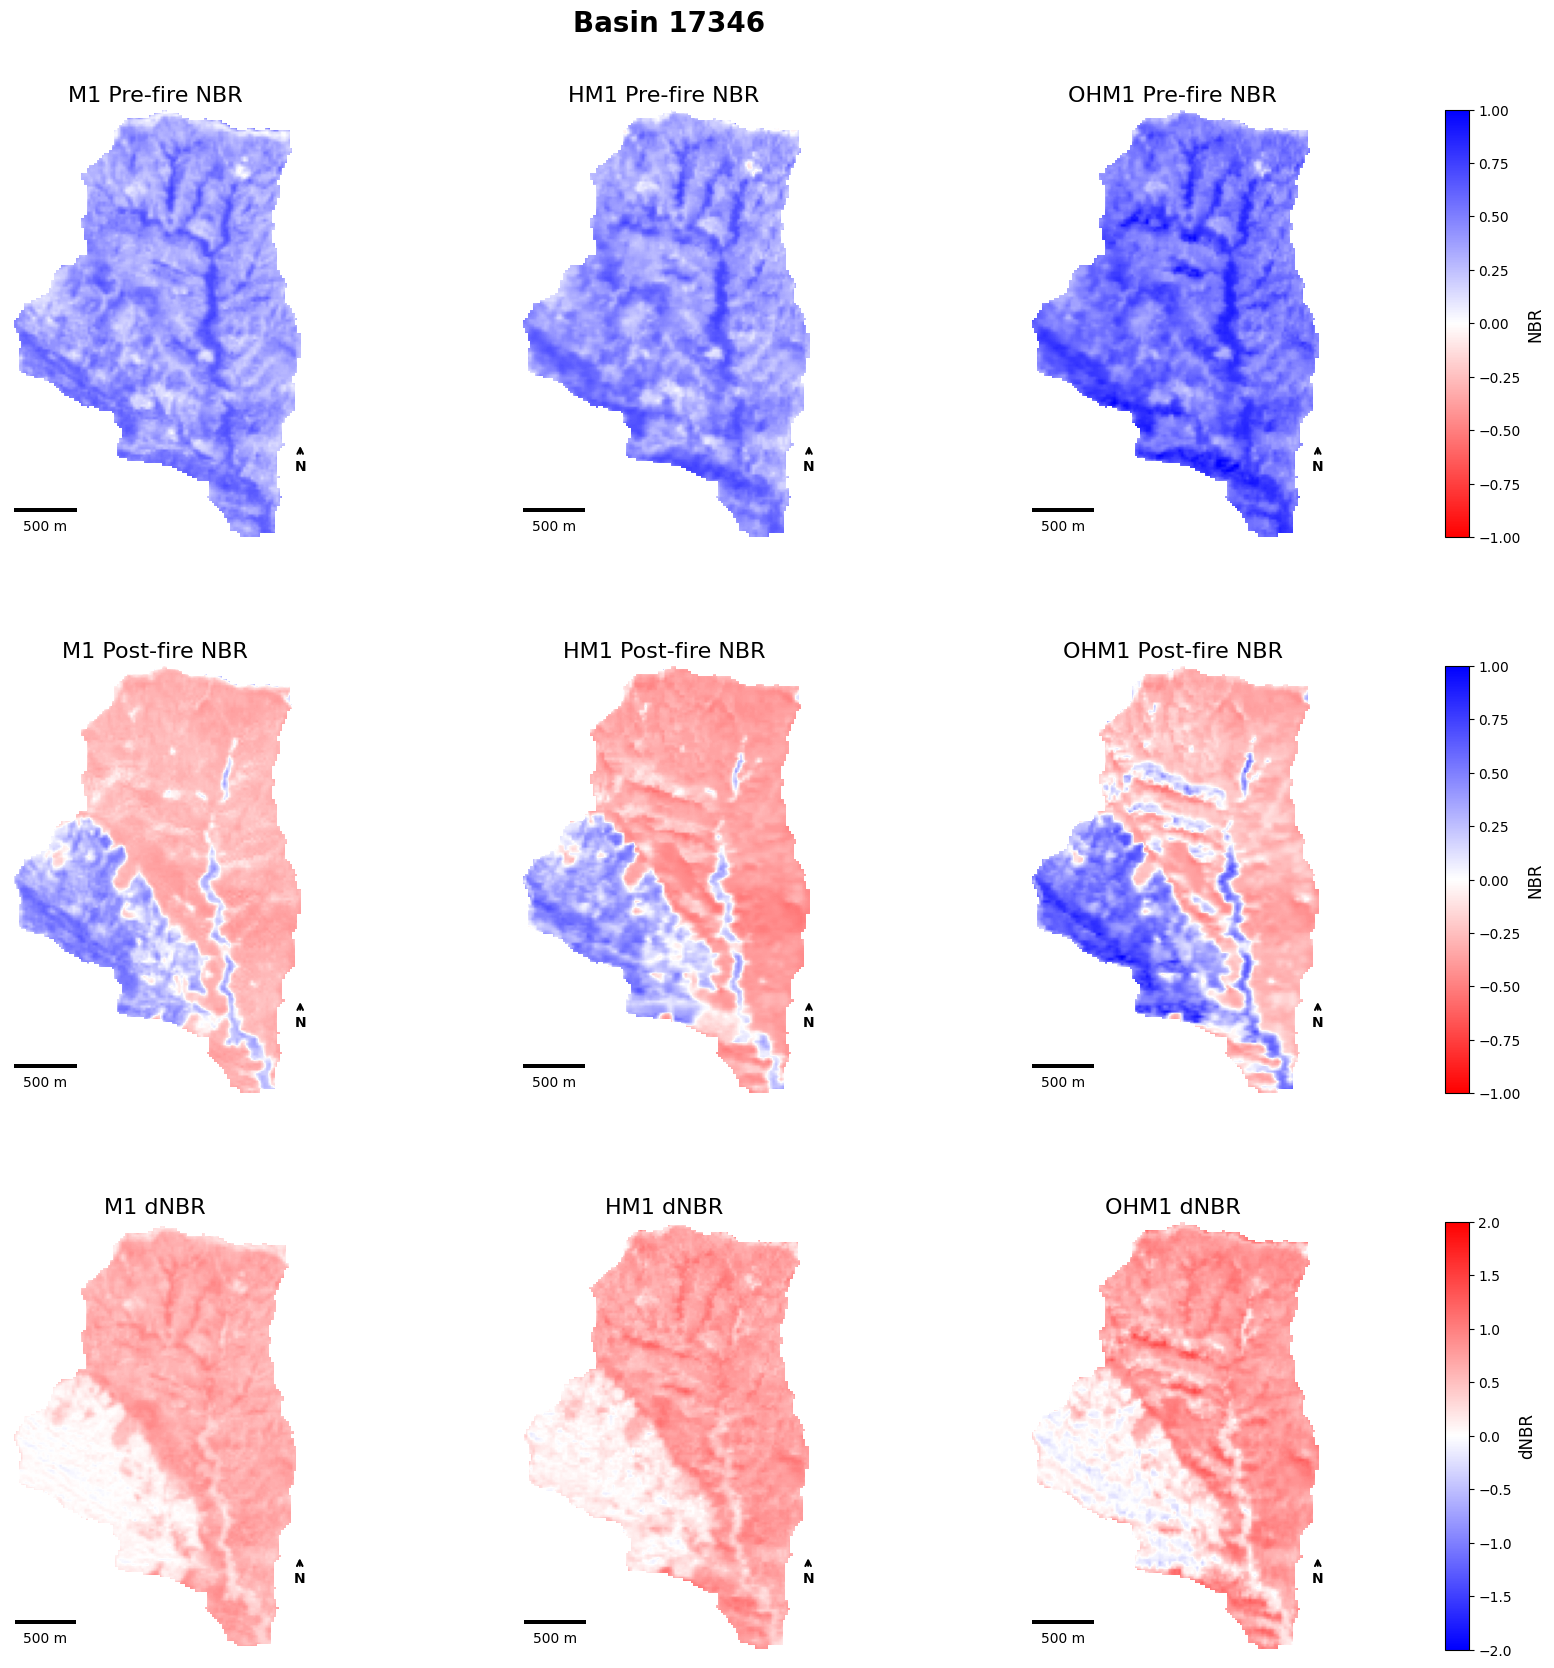

In [70]:
vmin = -1
vmax = 1
vmin_dnbr = -2
vmax_dnbr = 2

# Use gridspec for better control over shared colorbars
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(3, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], wspace=0.1, hspace=0.3)

axes = [[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(3)]
cbar_axes = [fig.add_subplot(gs[row, 3]) for row in range(3)]

# ── helper: north arrow ──────────────────────────────────────────────────────
def add_north_arrow(ax, x=1, y=0.15, size=0.07):
    ax.annotate(
        'N', xy=(x, y + size), xytext=(x, y),
        xycoords='axes fraction', textcoords='axes fraction',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        color='black'
    )

# ── helper: scale bar ────────────────────────────────────────────────────────
def add_scalebar(ax):
    scalebar = ScaleBar(
        dx=20, units="m",
        location="lower left",
        color="black", box_alpha=0.5,
        fixed_value=500
    )
    ax.add_artist(scalebar)

# ── Row 1: Pre-fire NBR ──────────────────────────────────────────────────────
datasets_row1 = [M1_nbr_pre, HM1_nbr_pre, OHM1_nbr_pre]
titles_row1   = ['M1 Pre-fire NBR', 'HM1 Pre-fire NBR', 'OHM1 Pre-fire NBR']

for col, (data, title) in enumerate(zip(datasets_row1, titles_row1)):
    im = axes[0][col].imshow(data, cmap='bwr_r', vmin=vmin, vmax=vmax)
    axes[0][col].set_title(title, fontsize=16)
    axes[0][col].axis('off')
    add_scalebar(axes[0][col])
    add_north_arrow(axes[0][col])

fig.colorbar(im, cax=cbar_axes[0])
cbar_axes[0].set_ylabel('NBR', fontsize=12)

# ── Row 2: Post-fire NBR ─────────────────────────────────────────────────────
datasets_row2 = [M1_nbr_post, HM1_nbr_post, OHM1_nbr_post]
titles_row2   = ['M1 Post-fire NBR', 'HM1 Post-fire NBR', 'OHM1 Post-fire NBR']

for col, (data, title) in enumerate(zip(datasets_row2, titles_row2)):
    im = axes[1][col].imshow(data, cmap='bwr_r', vmin=vmin, vmax=vmax)
    axes[1][col].set_title(title, fontsize=16)
    axes[1][col].axis('off')
    add_scalebar(axes[1][col])
    add_north_arrow(axes[1][col])

fig.colorbar(im, cax=cbar_axes[1])
cbar_axes[1].set_ylabel('NBR', fontsize=12)

# ── Row 3: dNBR ──────────────────────────────────────────────────────────────
datasets_row3 = [M1_dnbr, HM1_dnbr, OHM1_dnbr]
titles_row3   = ['M1 dNBR', 'HM1 dNBR', 'OHM1 dNBR']

for col, (data, title) in enumerate(zip(datasets_row3, titles_row3)):
    im = axes[2][col].imshow(data, cmap='bwr', vmin=vmin_dnbr, vmax=vmax_dnbr)
    axes[2][col].set_title(title, fontsize=16)
    axes[2][col].axis('off')
    add_scalebar(axes[2][col])
    add_north_arrow(axes[2][col])

fig.colorbar(im, cax=cbar_axes[2])
cbar_axes[2].set_ylabel('dNBR', fontsize=12)

plt.suptitle(f'Basin {basin}', fontsize=20, fontweight='bold', y=.93)
plt.tight_layout()
plt.savefig(out + f'Basin_{basin}_NBR_dNBR_comparison.svg', dpi=600, bbox_inches='tight')
plt.show()